Why I'm interested:
*   Veritasium video: https://www.youtube.com/watch?v=A5w-dEgIU1M
*   "Psychohistory" aspect: Quantifying complex human behaviors, e.g. stock market
*   Python modeling practice

See Also:
*   "Trillion Dollar Bet" by PBS/NOVA: https://www.pbs.org/wgbh/nova/stockmarket/formula.html
*   "Notes on an Interactive Visualization for the Black-Scholes Model" by Nowhere Near Ithaca: https://www.nowherenearithaca.com/2016/05/notes-on-interactive-visualization-for.html

Cool info:
* "The Greeks," a list of partial derivatives, include:
   *   Delta (change in option value as stock price changes)
   *   Bromma (change in option value as strike price changes)
   *   Theta (change in option value as time to expiration changes)
   *   Vega (change in option value as risk-free rate changes)
   *   Rho (change in option value as risk-free rate changes)
   *   Gamma (change in delta as stock price changes)
   *   Vanna (change in delta as volatility vhanges)
   *   Charm (change in delta as time to expiration changes)
   *   Vomma (change in vega as volatility changes)
   *   Veta (change in vega as time to expiration changes)

TODO:
*   Rewrite using this model: https://theaiquant.medium.com/mastering-the-black-scholes-model-with-python-a-comprehensive-guide-to-option-pricing-11af712697b7

In [ ]:
import math
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# From @DataScience-ProF 's treatment: https://medium.com/@TheDataScience-ProF/black-scholes-model-in-python-2f19c3db7a4a

"""
S: spot price of underlying asset
K: strike price of option
T: time to expiration (in years)
r: risk-free interest rate
sigma: volatility of underlying asset
option: the type of option, either 'call' or 'put' (default is 'call)
"""
def black_scholes(S, K, T, r, sigma, option):
  d1 = (math.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * math.sqrt(T))
  d2 = d1 - (sigma * math.sqrt(T))

  if option == 'call':
    return S * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)
  if option == 'put':
    return K * math.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

In [ ]:
# Let:
S = 42 # price of the stock
K = 40 # when the option expires, can purchase for $40 regardless of current price
T = 0.5 # 6-month expiration duration
r = 0.1 # Risk-Free Rate (Check current yield on 10-year U.S. Treasury bond)
sigma = 0.2 # volatility, standard deviation of stock prices (20%)

call_price = black_scholes(S, K, T, r, sigma, 'call')
put_price = black_scholes(S, K, T, r, sigma, 'put')

print(f'Call price: {call_price:.2f}')
print(f'Put price: {put_price:.2f}')

Call price: 4.76
Put price: 0.81


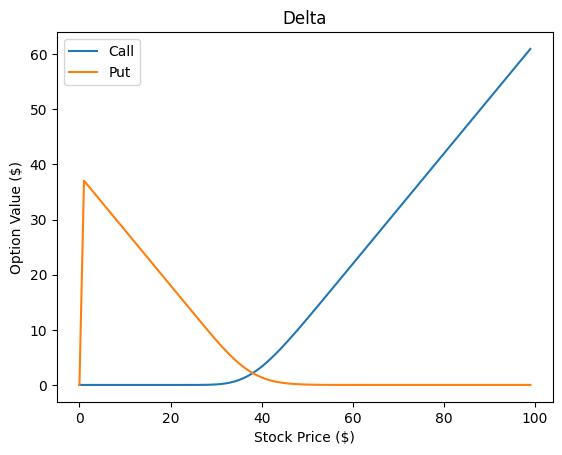

In [ ]:
# DELTA

priceInputs = np.zeros(100)
putOutputs = np.zeros(100)
callOutputs = np.zeros(100)

for s in range(1, 100):
  priceInputs[s] = s
  #print(priceInputs[s])
  callOutputs[s] = black_scholes(priceInputs[s], K, T, r, sigma, 'call')
  putOutputs[s] = black_scholes(priceInputs[s], K, T, r, sigma, 'put')

# Visualize first Greek, Delta:
plt.ylabel('Option Value ($)')
plt.xlabel('Stock Price ($)')
plt.title('Delta')
plt.plot(priceInputs, callOutputs)
plt.plot(priceInputs, putOutputs)
plt.legend(['Call', 'Put'])

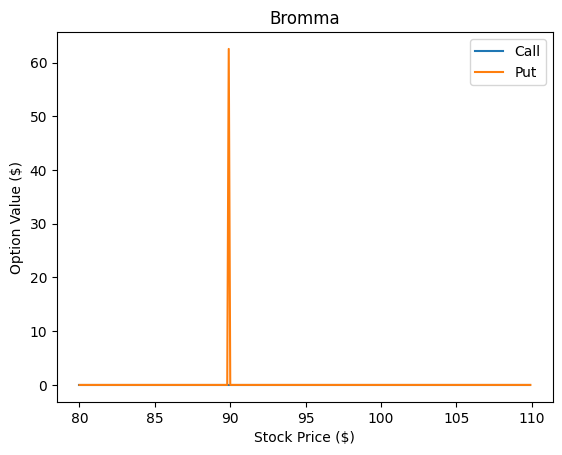

In [ ]:
# BROMMA

start = 80
stop = 110
d = 0.1
indices = int((stop - start) / d)

strikeInputs = np.zeros(indices)
putOutputs = np.zeros(indices)
callOutputs = np.zeros(indices)

for k in range(indices):
  strikeInputs[k] = start + k * d
  #print(priceInputs[k])
  callOutputs[s] = black_scholes(S, strikeInputs[k], T, r, sigma, 'call')
  putOutputs[s] = black_scholes(S, strikeInputs[k], T, r, sigma, 'put')

# Visualize first Greek, Delta:
plt.ylabel('Option Value ($)')
plt.xlabel('Stock Price ($)')
plt.title('Bromma')
plt.plot(strikeInputs, callOutputs)
plt.plot(strikeInputs, putOutputs)
plt.legend(['Call', 'Put'])